# Importación de librerías

In [1]:
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import filters_and_features as ff
import data_processor as dp
import numpy as np
from sklearn.decomposition import PCA

# Importación de datos

In [2]:
df = dp.lectura(mode=3) # Leyendo 2 primeros individuos
df_val = dp.lectura(mode=4) # Leyendo 10mo individuo

Se crea el dataframe df_block

In [3]:
df_block = dp.create_df_block(df)
df_block_val = dp.create_df_block(df_val)

In [4]:
del df
del df_val

Se limpia y visualiza el contenido

In [5]:
dp.balance(df_block)
dp.balance(df_block_val)
print(df_block['stimulus'].value_counts())
print(df_block_val['stimulus'].value_counts())

stimulus
1     228
0     228
3     228
4     228
6     228
9     228
10    228
11    228
Name: count, dtype: int64
stimulus
1     72
3     72
0     72
4     72
6     72
9     72
10    72
11    72
Name: count, dtype: int64


# Filtro

In [6]:
df_block_filtered = dp.filter(df_block)
df_block_filtered_val = dp.filter(df_block_val)

Procesando: 100%|██████████| 3/3 [00:20<00:00,  6.75s/it]


In [7]:
del df_block
del df_block_val

# Extracción de características

In [8]:
df_block_features = dp.gen_carac(df_block_filtered)
df_block_features_val = dp.gen_carac(df_block_filtered_val)

Extrayendo Características: 100%|██████████| 576/576 [00:21<00:00, 26.73it/s]


In [9]:
del df_block_filtered
del df_block_filtered_val

In [10]:
df_block_features.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,1824.000000,1.824000e+03,1824.000000,1824.000000,1824.000000,1.824000e+03,1824.000000,1.824000e+03,1824.000000,1824.000000,...,1.824000e+03,1824.000000,1.824000e+03,1.824000e+03,1824.000000,1.824000e+03,1824.000000,1824.000000,1824.000000,1824.000000
mean,0.000035,4.440878e-08,0.000021,0.115502,0.000009,7.250167e-09,0.001988,1.555890e-12,218.770435,83.175987,...,3.378790e-06,0.014219,1.936023e-06,7.354455e-10,0.000252,1.795454e-13,205.453944,67.849781,1731.513706,5.500000
std,0.000017,2.490132e-07,0.000009,0.063291,0.000003,8.242473e-09,0.001046,1.701302e-12,21.078178,16.360156,...,3.851283e-06,0.012079,1.714956e-06,2.025044e-08,0.000370,5.219112e-12,37.286178,31.592673,469.134700,3.906196
min,0.000009,-1.415412e-06,0.000005,0.019234,0.000002,2.924576e-10,0.000441,9.713446e-14,168.856813,43.000000,...,3.651399e-08,0.000197,2.235061e-08,8.639738e-15,0.000003,2.255880e-18,97.554654,13.000000,681.000000,0.000000
25%,0.000023,-5.943557e-08,0.000014,0.069901,0.000006,2.407566e-09,0.001244,5.415942e-13,202.796536,70.000000,...,7.351966e-08,0.000545,4.807201e-08,4.308974e-14,0.000006,8.798333e-18,178.352221,44.000000,1410.000000,2.500000
50%,0.000031,4.535458e-08,0.000019,0.100087,0.000009,4.534613e-09,0.001728,9.935530e-13,214.266393,81.000000,...,3.371886e-06,0.014639,2.042831e-06,9.987833e-11,0.000241,2.148529e-14,190.591188,54.000000,1561.000000,5.000000
75%,0.000042,1.516010e-07,0.000025,0.146314,0.000011,8.552229e-09,0.002427,1.831365e-12,233.902618,96.000000,...,4.908923e-06,0.021763,2.834489e-06,2.545441e-10,0.000374,5.619188e-14,252.990611,112.000000,2264.750000,9.250000
max,0.000130,1.795797e-06,0.000071,0.482888,0.000023,8.499703e-08,0.007519,1.721020e-11,281.225641,127.000000,...,9.765064e-05,0.150995,1.735379e-05,8.629341e-07,0.012427,2.225473e-10,271.180385,121.000000,2698.000000,11.000000


In [11]:
df_block_features_val.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,576.000000,5.760000e+02,576.000000,576.000000,576.000000,5.760000e+02,576.000000,5.760000e+02,576.000000,576.000000,...,5.760000e+02,576.000000,5.760000e+02,5.760000e+02,576.000000,5.760000e+02,576.000000,576.000000,576.000000,576.000000
mean,0.000054,-3.483346e-07,0.000031,0.148623,0.000013,2.574241e-08,0.002760,5.662918e-12,208.050034,76.164931,...,6.037135e-08,0.000441,3.991880e-08,2.936949e-14,0.000005,6.153835e-18,256.605929,113.138889,2345.967014,5.500000
std,0.000050,3.303199e-06,0.000021,0.084112,0.000007,9.206926e-08,0.001739,2.014302e-11,25.300267,17.117768,...,1.422671e-08,0.000114,1.026684e-08,1.309449e-14,0.000001,2.682883e-18,4.190429,2.176910,250.522794,3.908519
min,0.000011,-2.906444e-05,0.000007,0.025483,0.000003,5.400378e-10,0.000566,1.299651e-13,94.063944,10.000000,...,1.787477e-08,0.000107,8.291132e-09,4.223609e-15,0.000002,1.018640e-18,244.808350,105.000000,1370.000000,0.000000
25%,0.000031,-2.413810e-07,0.000019,0.088818,0.000009,4.316615e-09,0.001642,9.994087e-13,196.490553,67.750000,...,5.012977e-08,0.000359,3.260794e-08,1.942762e-14,0.000004,4.149849e-18,253.695157,112.000000,2285.750000,2.500000
50%,0.000042,-1.045826e-08,0.000026,0.127440,0.000011,8.581536e-09,0.002338,1.855104e-12,207.084448,75.000000,...,5.887010e-08,0.000432,3.919768e-08,2.650359e-14,0.000005,5.562147e-18,256.180540,113.000000,2391.500000,5.000000
75%,0.000063,1.471701e-07,0.000036,0.187032,0.000015,1.893904e-08,0.003494,4.050380e-12,221.716491,86.000000,...,6.852699e-08,0.000512,4.559479e-08,3.635176e-14,0.000005,7.471643e-18,258.979676,114.000000,2542.000000,9.250000
max,0.000499,3.425241e-05,0.000197,0.517186,0.000058,1.161362e-06,0.015254,2.497410e-10,263.304490,112.000000,...,9.298707e-08,0.000720,6.389218e-08,6.593552e-14,0.000007,1.306982e-17,278.536704,121.000000,2668.000000,11.000000


# Normalización

In [12]:
scaler, df_block_normalized = dp.normalize(df_block_features)
df_block_normalized_val = dp.normalize_test_data(scaler, df_block_features_val)

In [13]:
del df_block_features
del df_block_features_val

In [14]:
df_block_normalized.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,1.824000e+03,1.824000e+03,1.824000e+03,1.824000e+03,1.824000e+03,1.824000e+03,1.824000e+03,1824.000000,1.824000e+03,1.824000e+03,...,1.824000e+03,1.824000e+03,1.824000e+03,1824.000000,1.824000e+03,1.824000e+03,1.824000e+03,1.824000e+03,1.824000e+03,1824.000000
mean,-3.116416e-17,-1.558208e-17,2.181491e-16,-1.246566e-16,-1.558208e-17,-3.116416e-17,6.232831e-17,0.000000,3.116416e-17,1.869849e-16,...,1.012835e-16,2.337312e-17,-1.558208e-17,0.000000,1.558208e-17,1.947760e-18,3.272236e-16,1.246566e-16,-7.791039e-17,5.500000
std,1.000274e+00,1.000274e+00,1.000274e+00,1.000274e+00,1.000274e+00,1.000274e+00,1.000274e+00,1.000274,1.000274e+00,1.000274e+00,...,1.000274e+00,1.000274e+00,1.000274e+00,1.000274,1.000274e+00,1.000274e+00,1.000274e+00,1.000274e+00,1.000274e+00,3.906196
min,-1.501433e+00,-5.864031e+00,-1.771408e+00,-1.521455e+00,-2.097893e+00,-8.443603e-01,-1.478487e+00,-0.857670,-2.368673e+00,-2.456395e+00,...,-8.680725e-01,-1.161191e+00,-1.116178e+00,-0.036327,-6.734137e-01,-3.441053e-02,-2.894608e+00,-1.736631e+00,-2.239872e+00,0.000000
25%,-7.093667e-01,-4.171379e-01,-7.483553e-01,-7.206998e-01,-7.600324e-01,-5.876791e-01,-7.113773e-01,-0.596352,-7.580484e-01,-8.055914e-01,...,-8.584612e-01,-1.132417e+00,-1.101176e+00,-0.036325,-6.644630e-01,-3.440928e-02,-7.270564e-01,-7.551220e-01,-6.855214e-01,2.500000
50%,-2.378029e-01,3.799235e-03,-1.725669e-01,-2.436315e-01,-9.080697e-02,-3.295490e-01,-2.491122e-01,-0.330624,-2.137413e-01,-1.330417e-01,...,-1.793220e-03,3.478172e-02,6.229763e-02,-0.031394,-2.837874e-02,-3.029318e-02,-3.987223e-01,-4.385061e-01,-3.635640e-01,5.000000
75%,4.378932e-01,4.305862e-01,5.521694e-01,4.869635e-01,6.275800e-01,1.580132e-01,4.191795e-01,0.161964,7.181044e-01,7.840714e-01,...,3.974137e-01,6.247128e-01,5.240440e-01,-0.023754,3.297394e-01,-2.364145e-02,1.275264e+00,1.397866e+00,1.136950e+00,9.250000
max,5.524023e+00,7.035243e+00,5.730844e+00,5.806320e+00,4.186360e+00,9.435055e+00,5.286292e+00,9.203896,2.963839e+00,2.679439e+00,...,2.448475e+01,1.132696e+01,8.992644e+00,42.588452,3.292816e+01,4.261812e+01,1.763240e+00,1.682820e+00,2.060712e+00,11.000000


In [15]:
df_block_normalized_val.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,...,576.000000,576.000000,576.000000,5.760000e+02,576.000000,5.760000e+02,576.000000,576.000000,576.000000,576.000000
mean,1.087885,-1.577632,1.154070,0.523454,1.283767,2.244146,0.737538,2.414712,-0.508741,-0.428662,...,-0.861876,-1.141024,-1.105931,-3.632601e-02,-0.667596,-3.440978e-02,1.372252,1.433925,1.310118,5.500000
std,2.934599,13.268796,2.362759,1.329348,2.135150,11.173164,1.661940,11.843017,1.200635,1.046595,...,0.003695,0.009451,0.005988,6.468047e-07,0.002863,5.141907e-07,0.112416,0.068924,0.534157,3.908519
min,-1.380924,-116.928887,-1.539077,-1.422694,-1.778139,-0.814315,-1.359005,-0.838368,-5.918002,-4.474044,...,-0.872914,-1.168644,-1.124379,-3.632725e-02,-0.675522,-3.441077e-02,1.055758,1.176235,-0.770808,0.000000
25%,-0.239253,-1.148004,-0.213419,-0.421726,-0.105855,-0.356004,-0.330575,-0.327181,-1.057302,-0.943158,...,-0.864536,-1.147822,-1.110196,-3.632650e-02,-0.669715,-3.441017e-02,1.294164,1.397866,1.181725,2.500000
50%,0.429326,-0.220398,0.607419,0.188678,0.759672,0.161570,0.334225,0.175922,-0.554564,-0.499887,...,-0.862266,-1.141731,-1.106352,-3.632615e-02,-0.667937,-3.440990e-02,1.360840,1.429528,1.407202,5.000000
75%,1.626846,0.412787,1.824120,1.130482,1.980728,1.418516,1.439678,1.466626,0.139806,0.172663,...,-0.859758,-1.135127,-1.102621,-3.632566e-02,-0.665794,-3.440953e-02,1.435932,1.461189,1.728093,9.250000
max,27.072863,137.411920,20.273060,6.348384,15.095740,140.058466,12.680050,145.919555,2.113383,1.762325,...,-0.853405,-1.117921,-1.091949,-3.632420e-02,-0.660729,-3.440846e-02,1.960587,1.682820,1.996747,11.000000


# Creación de dataframes de entrenamiento y testeo

In [16]:
y = df_block_normalized.iloc[:, -1]
X = df_block_normalized.iloc[:, :-1]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

In [17]:
y_val = df_block_normalized_val.iloc[:, -1]
X_val = df_block_normalized_val.iloc[:, :-1]

In [18]:
del df_block_normalized
del df_block_normalized_val

In [19]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)

(1276, 154) (1276,)
(576, 154) (576,)


# Entrenamiento y testeo del modelo

Importamos librerías

In [20]:
# Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Rotation forest
from sktime.classification.sklearn import RotationForest
from sktime.datasets import load_unit_test
from sktime.datatypes._panel._convert import from_nested_to_3d_numpy

# Artificial Neural Networks (ANN)
import setuptools.dist
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [21]:
# Visualization libraries

import seaborn as sns

Random forest

In [22]:
rf = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf.fit(X_train, y_train)
y_pred_RanF = rf.predict(X_test)
y_pred_RanF_val = rf.predict(X_val)

Rotation forest

In [23]:
clf = RotationForest(n_estimators=300)
clf.fit(X_train, y_train)
y_pred_RotF = clf.predict(X_test)
y_pred_RotF_val = clf.predict(X_val)

Artificial Neural Networks (ANN)

In [24]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann = le.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_val = le.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step


# Resultados

Random forest

Test data

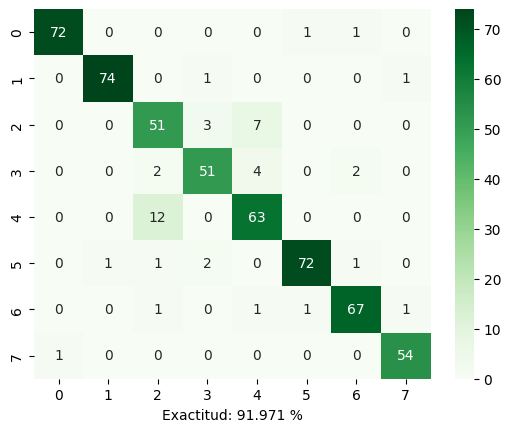

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        74
           1       0.99      0.97      0.98        76
           3       0.76      0.84      0.80        61
           4       0.89      0.86      0.88        59
           6       0.84      0.84      0.84        75
           9       0.97      0.94      0.95        77
          10       0.94      0.94      0.94        71
          11       0.96      0.98      0.97        55

    accuracy                           0.92       548
   macro avg       0.92      0.92      0.92       548
weighted avg       0.92      0.92      0.92       548



In [25]:
sns.heatmap(confusion_matrix(y_pred_RanF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF, y_test))

Validation data

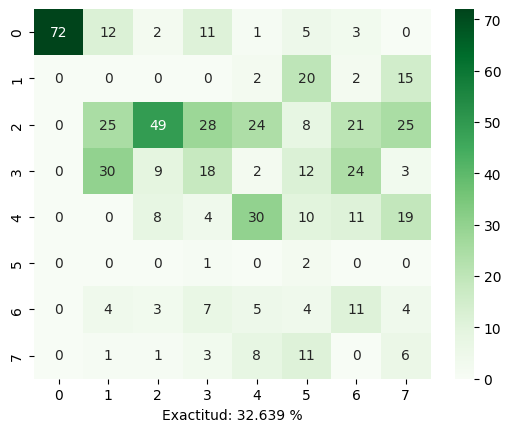

              precision    recall  f1-score   support

           0       1.00      0.68      0.81       106
           1       0.00      0.00      0.00        39
           3       0.68      0.27      0.39       180
           4       0.25      0.18      0.21        98
           6       0.42      0.37      0.39        82
           9       0.03      0.67      0.05         3
          10       0.15      0.29      0.20        38
          11       0.08      0.20      0.12        30

    accuracy                           0.33       576
   macro avg       0.33      0.33      0.27       576
weighted avg       0.51      0.33      0.38       576



In [26]:
sns.heatmap(confusion_matrix(y_pred_RanF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_val, y_val))

Rotation forest

Test data

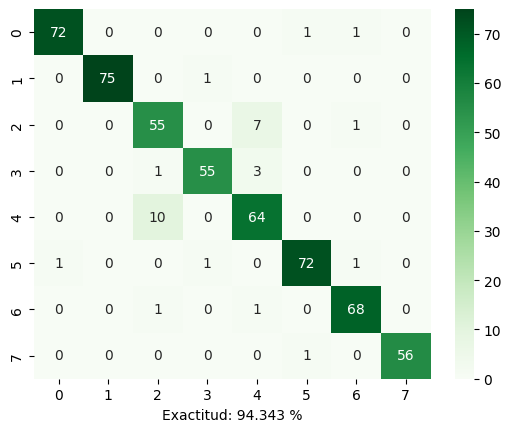

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        74
           1       1.00      0.99      0.99        76
           3       0.82      0.87      0.85        63
           4       0.96      0.93      0.95        59
           6       0.85      0.86      0.86        74
           9       0.97      0.96      0.97        75
          10       0.96      0.97      0.96        70
          11       1.00      0.98      0.99        57

    accuracy                           0.94       548
   macro avg       0.94      0.94      0.94       548
weighted avg       0.94      0.94      0.94       548



In [27]:
sns.heatmap(confusion_matrix(y_pred_RotF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF, y_test))

Validation data

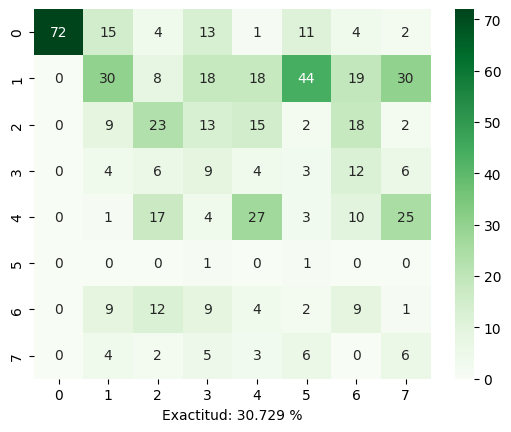

              precision    recall  f1-score   support

           0       1.00      0.59      0.74       122
           1       0.42      0.18      0.25       167
           3       0.32      0.28      0.30        82
           4       0.12      0.20      0.16        44
           6       0.38      0.31      0.34        87
           9       0.01      0.50      0.03         2
          10       0.12      0.20      0.15        46
          11       0.08      0.23      0.12        26

    accuracy                           0.31       576
   macro avg       0.31      0.31      0.26       576
weighted avg       0.46      0.31      0.35       576



In [28]:
sns.heatmap(confusion_matrix(y_pred_RotF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_val, y_val))

Artificial Neural Networks (ANN)

Test data

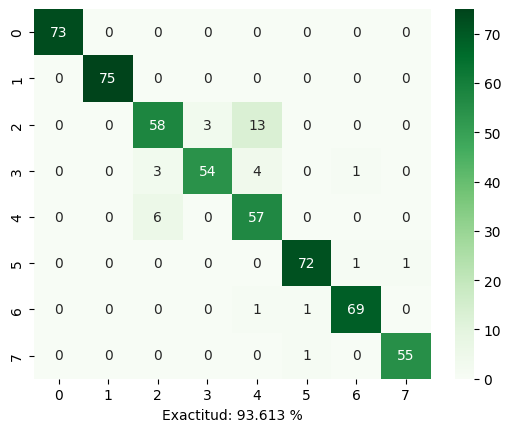

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00        75
           3       0.87      0.78      0.82        74
           4       0.95      0.87      0.91        62
           6       0.76      0.90      0.83        63
           9       0.97      0.97      0.97        74
          10       0.97      0.97      0.97        71
          11       0.98      0.98      0.98        56

    accuracy                           0.94       548
   macro avg       0.94      0.94      0.94       548
weighted avg       0.94      0.94      0.94       548



In [29]:
sns.heatmap(confusion_matrix(y_pred_ann, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann, y_test))

Validation data

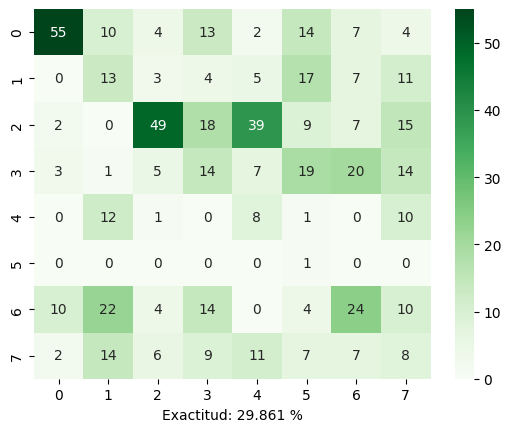

              precision    recall  f1-score   support

           0       0.76      0.50      0.61       109
           1       0.18      0.22      0.20        60
           3       0.68      0.35      0.46       139
           4       0.19      0.17      0.18        83
           6       0.11      0.25      0.15        32
           9       0.01      1.00      0.03         1
          10       0.33      0.27      0.30        88
          11       0.11      0.12      0.12        64

    accuracy                           0.30       576
   macro avg       0.30      0.36      0.26       576
weighted avg       0.43      0.30      0.34       576



In [30]:
sns.heatmap(confusion_matrix(y_pred_ann_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_val, y_val))

# Con PCA

In [31]:
pca = PCA(n_components=80)

X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

X_pca_val = pca.fit_transform(X_val)

In [32]:
print('Sin PCA')
print(X.shape)
print(X_pca.shape)
print('Con PCA')
print(X_val.shape)
print(X_pca_val.shape)

Sin PCA
(1824, 154)
(1824, 80)
Con PCA
(576, 154)
(576, 80)


Random forest

In [33]:
rf_pca = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf_pca.fit(X_train_pca, y_train)
y_pred_RanF_pca = rf_pca.predict(X_test_pca)
y_pred_RanF_pca_val = rf_pca.predict(X_pca_val)

Rotation forest

In [34]:
clf_pca = RotationForest(n_estimators=300)
clf_pca.fit(X_train_pca, y_train)
y_pred_RotF_pca = clf_pca.predict(X_test_pca)
y_pred_RotF_pca_val = clf_pca.predict(X_pca_val)

Artificial Neural Networks (ANN)

In [35]:
le_pca = LabelEncoder()
y_train_enc = le_pca.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le_pca.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_pca, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test_pca)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann_pca = le_pca.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_pca_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_pca_val = le_pca.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step


# Resultados

Random forest

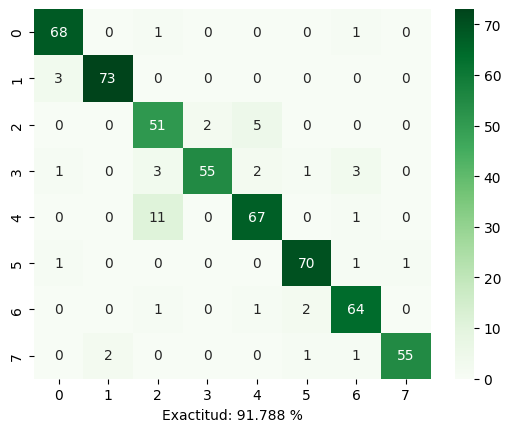

              precision    recall  f1-score   support

           0       0.93      0.97      0.95        70
           1       0.97      0.96      0.97        76
           3       0.76      0.88      0.82        58
           4       0.96      0.85      0.90        65
           6       0.89      0.85      0.87        79
           9       0.95      0.96      0.95        73
          10       0.90      0.94      0.92        68
          11       0.98      0.93      0.96        59

    accuracy                           0.92       548
   macro avg       0.92      0.92      0.92       548
weighted avg       0.92      0.92      0.92       548



In [36]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca, y_test))

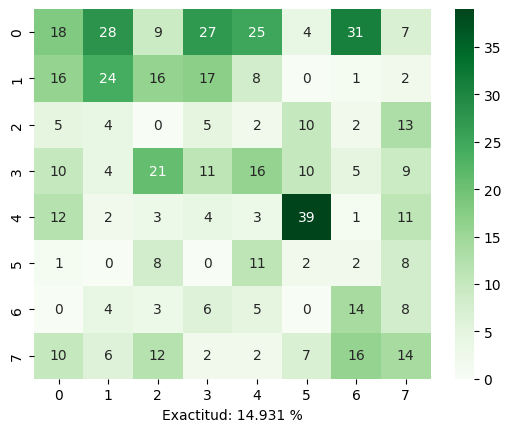

              precision    recall  f1-score   support

           0       0.25      0.12      0.16       149
           1       0.33      0.29      0.31        84
           3       0.00      0.00      0.00        41
           4       0.15      0.13      0.14        86
           6       0.04      0.04      0.04        75
           9       0.03      0.06      0.04        32
          10       0.19      0.35      0.25        40
          11       0.19      0.20      0.20        69

    accuracy                           0.15       576
   macro avg       0.15      0.15      0.14       576
weighted avg       0.18      0.15      0.16       576



In [37]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca_val, y_val))

Rotation forest

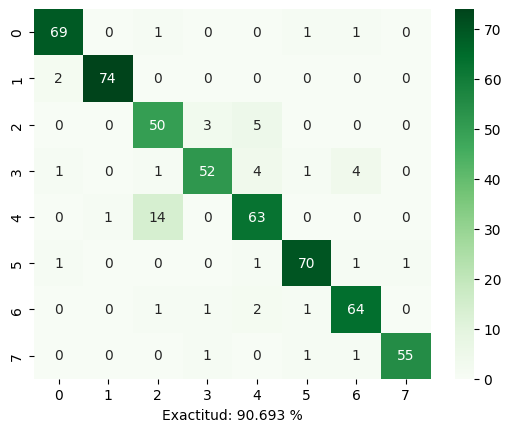

              precision    recall  f1-score   support

           0       0.95      0.96      0.95        72
           1       0.99      0.97      0.98        76
           3       0.75      0.86      0.80        58
           4       0.91      0.83      0.87        63
           6       0.84      0.81      0.82        78
           9       0.95      0.95      0.95        74
          10       0.90      0.93      0.91        69
          11       0.98      0.95      0.96        58

    accuracy                           0.91       548
   macro avg       0.91      0.91      0.91       548
weighted avg       0.91      0.91      0.91       548



In [38]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca, y_test))

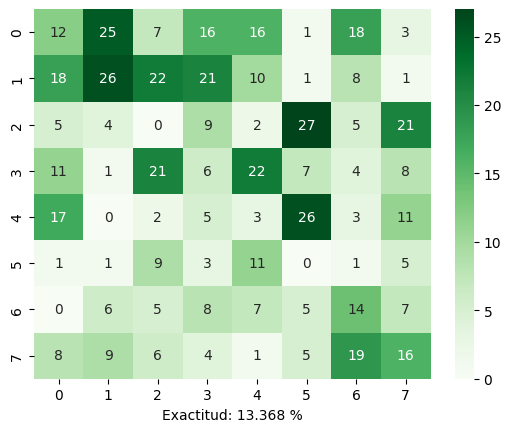

              precision    recall  f1-score   support

           0       0.17      0.12      0.14        98
           1       0.36      0.24      0.29       107
           3       0.00      0.00      0.00        73
           4       0.08      0.07      0.08        80
           6       0.04      0.04      0.04        67
           9       0.00      0.00      0.00        31
          10       0.19      0.27      0.23        52
          11       0.22      0.24      0.23        68

    accuracy                           0.13       576
   macro avg       0.13      0.12      0.13       576
weighted avg       0.16      0.13      0.14       576



In [39]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca_val, y_val))

Artificial Neural Networks (ANN)

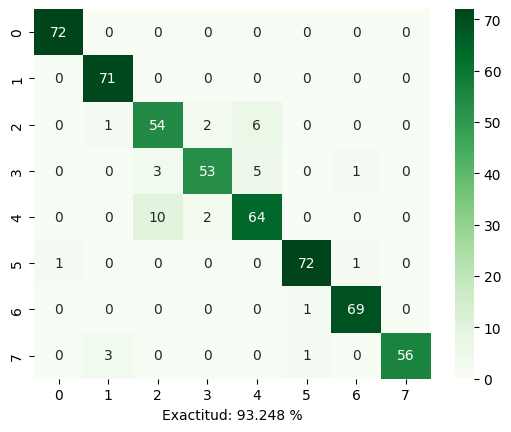

              precision    recall  f1-score   support

           0       0.99      1.00      0.99        72
           1       0.95      1.00      0.97        71
           3       0.81      0.86      0.83        63
           4       0.93      0.85      0.89        62
           6       0.85      0.84      0.85        76
           9       0.97      0.97      0.97        74
          10       0.97      0.99      0.98        70
          11       1.00      0.93      0.97        60

    accuracy                           0.93       548
   macro avg       0.93      0.93      0.93       548
weighted avg       0.93      0.93      0.93       548



In [40]:
sns.heatmap(confusion_matrix(y_pred_ann_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca, y_test))

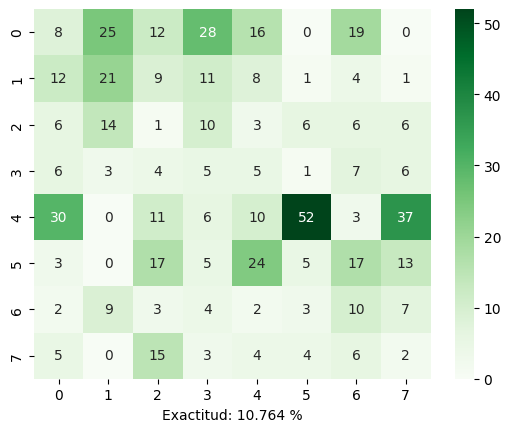

              precision    recall  f1-score   support

           0       0.11      0.07      0.09       108
           1       0.29      0.31      0.30        67
           3       0.01      0.02      0.02        52
           4       0.07      0.14      0.09        37
           6       0.14      0.07      0.09       149
           9       0.07      0.06      0.06        84
          10       0.14      0.25      0.18        40
          11       0.03      0.05      0.04        39

    accuracy                           0.11       576
   macro avg       0.11      0.12      0.11       576
weighted avg       0.12      0.11      0.11       576



In [41]:
sns.heatmap(confusion_matrix(y_pred_ann_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca_val, y_val))

Rpoerte de PCA

In [42]:
X

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,iemg_14,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14
0,-0.541271,0.135260,-0.531850,-0.477920,-0.311207,-0.475053,-0.528275,-0.502666,-0.859722,-1.050155,...,-0.840225,0.142565,0.301629,0.205679,-0.026946,0.232446,-0.026770,-0.269348,-0.533491,-0.602367
1,-0.251644,0.371851,-0.143909,-0.290199,0.005701,-0.363123,-0.315173,-0.313699,-0.367898,-0.499887,...,-0.423195,0.412867,0.534132,0.364528,-0.019287,0.547102,-0.018863,-0.356258,-0.311860,-0.824112
2,-0.910104,0.082754,-0.973139,-0.940425,-0.956000,-0.693599,-0.930086,-0.684627,-0.325340,-0.744450,...,-0.565470,0.040465,-0.132545,0.056694,-0.029916,0.043829,-0.027301,-0.640633,-0.565152,-1.131145
3,-0.536032,0.389719,-0.433695,-0.413375,-0.034453,-0.473586,-0.530445,-0.496877,-0.841816,-1.111296,...,-0.137545,0.029197,0.153152,0.059280,-0.028323,0.176903,-0.027797,-0.277413,-0.501829,-0.527741
4,-0.724570,0.198540,-0.747500,-0.734320,-0.615532,-0.597387,-0.748134,-0.595204,-0.739517,-0.989014,...,-0.060159,0.033488,0.035066,0.120637,-0.030499,0.047424,-0.029332,-0.338485,-0.343521,-0.881681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1819,0.311029,0.267651,0.704243,0.721737,1.238032,0.115771,0.355745,0.018105,-0.134138,0.172663,...,-0.018729,-0.861708,-1.138146,-1.105418,-0.036326,-0.667238,-0.034410,1.245364,1.302881,1.813380
1820,-0.524260,2.942187,-0.673398,-0.949840,-0.807321,-0.599854,-0.621236,-0.549646,0.892309,0.417226,...,-0.013210,-0.861642,-1.150741,-1.105455,-0.036326,-0.669372,-0.034410,1.301509,1.429528,0.026623
1821,-0.098508,-0.215330,0.111063,-0.147769,0.550868,-0.247502,-0.194406,-0.252492,-1.031582,-0.683310,...,-0.024261,-0.860251,-1.136792,-1.103603,-0.036326,-0.666271,-0.034410,1.356444,1.492851,1.337907
1822,0.451166,-0.492406,0.865095,0.805471,1.176304,0.239039,0.501533,0.175086,-0.199923,0.050381,...,-0.029850,-0.863007,-1.140664,-1.107578,-0.036326,-0.667915,-0.034410,1.570046,1.429528,1.928517
